# Train OnsetsAndFrames (jongwook architecture)

## Training Stages

| Stage | `max_files` | Approx. data | Purpose |
|-------|-------------|--------------|---------|
| 2 — small | 100 | ~4 hr | Tune hyperparameters, verify loss convergence |

---

## Hardware & Compute

| Property | Value |
|----------|-------|
| GPU | NVIDIA Tesla T4 |
| GPU VRAM | 15 GB |
| System RAM | 12.7 GB |
| Platform | Google Colab |
| Mixed Precision (AMP) | float16 via torch.amp.autocast |
| torch.compile | Enabled (PyTorch 2.0+) |
| TF32 | Disabled (T4 is Turing, not Ampere) |
| cuDNN benchmark | Enabled |

---

## Model

| Property | Value |
|----------|-------|
| Architecture | OnsetsAndFrames (jongwook PyTorch reimplementation) |
| model_complexity | 48 |
| model_size (hidden) | 768 (complexity × 16) |
| Total parameters | 26,491,256 (~26.5M) |
| Heads | onset, frame, offset (BCE), velocity (masked MSE) |
| Activations | post-sigmoid on onset/frame/offset; raw on velocity |
| Device | CUDA (T4) |

---

## Hyperparameters

| Hyperparameter | Value | Reference |
|----------------|-------|-----------|
| Optimizer | Adam | Hawthorne 2018a §3.2 |
| Learning rate | 6e-4 | Hawthorne 2018a §3.2 |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=3) | jongwook |
| Epochs | 50 | this run |
| Train batch size | 4 | jongwook default 8, reduced for T4 |
| Val batch size | 1 | this run |
| Per-param grad clip norm | 3.0 | jongwook |
| Loss: onset/frame/offset | F.binary_cross_entropy ( with pos_weight for onset and offset and frame ) | jongwook + Magenta + Curtis Hawthorne ONSETS AND FRAMES |
|'pos_weight_onset':  | 25.0 |
|'pos_weight_frame':  | 6.0 |
|'pos_weight_offset': | 25.0 |
| Loss: velocity | Masked MSE at onset positions | Hawthorne 2018a §3.2 |
| num_workers | 2 | jongwook |

---


## Segmentation & Data

| Property | Value |
|----------|-------|
| Dataset | MAESTRO v3.0.0 |
| Subset | 100 files (max_files=100) |
| Train segment length | 640 frames (~20s) — matches jongwook sequence_length=327,680 samples |
| Val segment length | 1920 frames (~60s) — 3 times train, fixed-size crops |
| Test segment | Full pieces — sliding window via sliding_windows() |
| Train shuffle | Yes |
| Val shuffle | No |
| drop_last | Train only |
| Augmentation | Pitch shift (train only) |
| Train batches | 25 (100 files ÷ batch_size=4) |
| Val batches | 50 |

---

## Tensor Shapes (verified)

| Tensor | Shape | Notes |
|--------|-------|-------|
| mel | (B, 229, 640) | log-mel spectrogram, freq-first |
| onset | (B, 640, 88) | binary piano roll |
| frame | (B, 640, 88) | binary piano roll |
| offset | (B, 640, 88) | binary piano roll |
| velocity | (B, 640, 88) | normalised [0,1] |

---

## Model Output at Initialisation (sanity check)

| Head | Min | Max | Expected |
|------|-----|-----|----------|
| onset | 0.486 | 0.516 | ~0.5 (random init, post-sigmoid) |
| frame | 0.467 | 0.534 | ~0.5 (random init, post-sigmoid) |
| offset | 0.486 | 0.516 | ~0.5 (random init, post-sigmoid) |
| velocity | -0.053 | 0.057 | ~0.0 (random init, no sigmoid) |

All heads initialise near uniform — correct behaviour before any training.

---

## Checkpointing & Outputs

All checkpoints are saved to Google Drive and survive Colab restarts.
Every run auto-creates `runs/<run_name>/` with:

- `checkpoints/` — `latest.pt` every epoch + `best.pt` on val loss improvement + `epoch_NNN.pt` every 5 epochs
- `plots/` — loss curve PNG (total + per-head) saved after every epoch
- `metrics.json` — all epoch losses + timing, updated live
- `timing_summary.json` — per-epoch and cumulative training time
- `config.json` — exact config used for this run

## Cell 1 — Environment setup

Run every session. Mounts Drive, installs packages, clones repo, sets paths.

In [11]:
# ── GPU check ─────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "No GPU! Change runtime to T4 GPU."
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU : Tesla T4
CUDA: 12.8
VRAM: 15.6 GB


In [12]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✓


In [13]:
# ── Clone / update repo ────────────────────────────────────────────────────
import os
from getpass import getpass

REPO_DIR = '/content/AMT_FYP'
TOKEN    = getpass('GitHub token: ')

if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://{TOKEN}@github.com/Mobinmo83/AMT_FYP.git {REPO_DIR}")
    print(f"Cloned → {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")
    print(f"Pulled latest → {REPO_DIR}")

GitHub token: ··········
Pulled latest → /content/AMT_FYP


In [4]:
%cd /content/AMT_FYP/piano_amt
!pip install -q -r requirements.txt # torch torchaudio pretty_midi pandas tqdm matplotlib pyyaml mir_eval
print("Packages installed ✓")

/content/AMT_FYP/piano_amt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.1 MB/s eta 0:00:00
Packages installed ✓


In [5]:
# ── sys.path + project root ────────────────────────────────────────────────
import sys

PROJECT_ROOT = '/content/AMT_FYP/piano_amt'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Quick sanity check
from src.constants import N_MELS, FRAMES_PER_SECOND, N_KEYS
assert N_MELS == 229 and abs(FRAMES_PER_SECOND - 31.25) < 1e-6 and N_KEYS == 88
print("Imports OK ✓")

Imports OK ✓


In [6]:
# ── Path constants  (edit ONLY these if your Drive layout differs) ──────────
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
RUNS_DIR     = f'{DRIVE_ROOT}/runs'

import os
os.makedirs(RUNS_DIR, exist_ok=True)

# Verify cache exists
import glob
npzs = glob.glob(f'{CACHE_DIR}/*.npz')
print(f"Cache files : {len(npzs)}")
assert len(npzs) > 0, "Run 02_build_cache.ipynb first!"
print(f"MAESTRO root: {MAESTRO_ROOT}")
print(f"Runs dir    : {RUNS_DIR}")

Cache files : 1276
MAESTRO root: /content/drive/MyDrive/piano_amt/maestro-v3.0.0
Runs dir    : /content/drive/MyDrive/piano_amt/runs


## Cell 2 — Training configuration

**Edit the `CONFIG` dict to choose your training stage.**

Key parameters:
- `run_name`: unique name saved to Drive — use descriptive names like `of_baseline_stage1`
- `max_files`: controls dataset size (None = full 962 training files)
- `model_complexity`: 48 = full jongwook model (~26M params); 16 = small debug model (~1M params)
- `epochs`: use fewer epochs for smoke/tiny tests; 30+ for real training
- `resume`: path to a `.pt` checkpoint to resume from; None to start fresh

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING CONFIGURATION — edit this cell
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Identity ───────────────────────────────────────────────────────────
    # Choose a descriptive name; results saved to RUNS_DIR/<run_name>/
    'run_name':   'OF_medium_test',   # <-- CHANGE THIS each run

    # ── Dataset size ──────────────────────────────────────────────────────
    # Stage 0 (smoke): max_files=5     (~10 min audio, 2 epochs, verify loop)
    # Stage 1 (tiny):  max_files=30    (~1 hr audio, 5 epochs)
    # Stage 2 (small): max_files=100   (~4 hr audio, 15 epochs)
    # Stage 3 (medium):max_files=400   (~20 hr audio, 30 epochs)
    # Stage 4 (full):  max_files=None  (~178 hr audio, 30+ epochs)
    'max_files':  800,

    # ── Model ─────────────────────────────────────────────────────────────
    # 48 = full jongwook (~26M params) — use for stage 2+
    # 16 = small debug (~1M params) — use for stage 0+1 to move faster
    'model_complexity': 48,

    # ── Training ─────────────────────────────────────────────────────────
    'epochs':        100,      # smoke=2, tiny=5, small=15, medium=30, full=30+
    'batch_size_train': 8,   # for training (can be 8 on better GPUs)
    'batch_size_val':   1,
    'lr':            6e-4,   # Hawthorne 2018a §3.2
    'max_grad_norm': 3.0,
    'num_workers':   0,
    'log_every':     10,     # print loss every N steps

    # Stage 2 (small,  max_files=100):  onset=25, frame=6,  offset=25
    # Stage 3 (medium, max_files=400):  onset=10, frame=3,  offset=10
    # Stage 4 (full,   max_files=None): onset=1,  frame=1,  offset=1   ← plain BCE like jongwook
    'pos_weight_onset':  8.0,
    'pos_weight_frame':   2.0,
    'pos_weight_offset': 8.0,

    # ── Resume from checkpoint (set to None to start fresh) ───────────────
    # Example: f'{RUNS_DIR}/of_baseline_stage1/checkpoints/best.pt'
    'resume': None,
}

# ─── Print config summary ─────────────────────────────────────────────────
print("Training configuration:")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

Training configuration:
  run_name            : OF_medium_test
  max_files           : 800
  model_complexity    : 48
  epochs              : 100
  batch_size_train    : 8
  batch_size_val      : 1
  lr                  : 0.0006
  max_grad_norm       : 3.0
  num_workers         : 0
  log_every           : 10
  pos_weight_onset    : 8.0
  pos_weight_frame    : 2.0
  pos_weight_offset   : 8.0
  resume              : None


## Cell 3 — Build model and inspect

In [8]:
import torch
from models.onsets_frames.model import OnsetsAndFrames

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

n_params = model.count_parameters()
print(f"Model          : OnsetsAndFrames")
print(f"model_complexity: {CONFIG['model_complexity']}")
print(f"Parameters     : {n_params:,}")
print(f"Device         : {device}")

# Quick forward pass to check shapes
model = model.to(device)
dummy = torch.zeros(2, 229, 640).to(device)
with torch.no_grad():
    out = model(dummy)
for k, v in out.items():
    print(f"  {k:10s}: {tuple(v.shape)}  min={v.min():.3f} max={v.max():.3f}")

assert out['onset'].shape  == (2, 640, 88), "Onset shape wrong"
assert out['frame'].shape  == (2, 640, 88), "Frame shape wrong"
assert out['offset'].shape == (2, 640, 88), "Offset shape wrong"
print("\nModel shapes OK ✓")

Model          : OnsetsAndFrames
model_complexity: 48
Parameters     : 26,491,256
Device         : cuda
  onset     : (2, 640, 88)  min=0.482 max=0.513
  frame     : (2, 640, 88)  min=0.459 max=0.549
  offset    : (2, 640, 88)  min=0.488 max=0.516
  velocity  : (2, 640, 88)  min=-0.074 max=0.062

Model shapes OK ✓


## Cell 4 — Build DataLoaders

In [ ]:
from src.dataloader import get_dataloader

train_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'train',
    batch_size     = CONFIG['batch_size_train'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = True,
    pin_memory     = True,
)
val_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'validation',
    batch_size     = CONFIG['batch_size_val'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = False,
    pin_memory     = True,
)
print(f"Train batches : {len(train_loader)}  (batch_size={CONFIG['batch_size_train']})")
print(f"Val batches   : {len(val_loader)}")

# Peek at one batch
batch = next(iter(train_loader))
print(f"\nSample batch:")
for k, v in batch.items():
    if hasattr(v, 'shape'):
        print(f"  {k:12s}: {tuple(v.shape)}")
print("DataLoaders OK ✓")



Train batches : 100  (batch_size=8)
Val batches   : 137

Sample batch:
  mel         : (8, 229, 640)
  onset       : (8, 640, 88)
  frame       : (8, 640, 88)
  offset      : (8, 640, 88)
  velocity    : (8, 640, 88)
DataLoaders OK ✓


In [ ]:

val_batch = next(iter(val_loader))
print(f"Val mel shape  : {val_batch['mel'].shape}")    # expect (B, 229, 1920)
print(f"Val onset shape: {val_batch['onset'].shape}")  # expect (B, 1920, 88)
train_batch = next(iter(train_loader))
print(f"Train mel shape: {train_batch['mel'].shape}")  # expect (B, 229, 640)

Val mel shape  : torch.Size([1, 229, 1920])
Val onset shape: torch.Size([1, 1920, 88])
Train mel shape: torch.Size([8, 229, 640])


## Cell 5 — Train

This cell runs the full training loop.  
Loss curves are saved to Drive after every epoch — if Colab disconnects,
you can resume from `best.pt` by setting `CONFIG['resume']` above.

**Watch:** the `[ep NNN step NNN]` lines show per-batch loss in real time.

In [ ]:
from models.onsets_frames.train import OnsetsFramesLoss, Trainer, RunDirectory

# Create run directory
run_dir = RunDirectory(RUNS_DIR, CONFIG['run_name'])

# Save config
import json
cfg_to_save = dict(CONFIG)
cfg_to_save.update({'maestro_root': MAESTRO_ROOT, 'cache_dir': CACHE_DIR,
                    'device': str(device)})
run_dir.save_config(cfg_to_save)

# Fresh model
model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

# Trainer with GPU optimizations
trainer = Trainer(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    device         = device,
    run_dir        = run_dir,
    lr             = CONFIG['lr'],
    # pos_weight     = CONFIG['pos_weight'],
    max_grad_norm  = CONFIG['max_grad_norm'],
    log_every      = CONFIG['log_every'],
    use_amp        = True,
    use_compile    = True,
    pos_weight_onset  = CONFIG['pos_weight_onset'],   # ADD
    pos_weight_frame  = CONFIG['pos_weight_frame'],   # ADD
    pos_weight_offset = CONFIG['pos_weight_offset'],  # ADD
)

# Resume from checkpoint if specified
start_epoch = 1
if CONFIG['resume']:
    ckpt_path = CONFIG['resume']
    print(f"Resuming from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    # Handle torch.compile wrapper
    model_to_load = trainer.model
    if hasattr(trainer.model, '_orig_mod'):
        model_to_load = trainer.model._orig_mod
    model_to_load.load_state_dict(ckpt['model_state'])

    if 'optimizer_state' in ckpt:
        trainer.optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'scheduler_state' in ckpt:
        trainer.scheduler.load_state_dict(ckpt['scheduler_state'])
    if 'scaler_state' in ckpt and trainer.scaler is not None:
        trainer.scaler.load_state_dict(ckpt['scaler_state'])

    start_epoch = ckpt['epoch'] + 1
    trainer.global_step = ckpt.get('global_step', 0)
    trainer.best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('inf')))
    print(f"  Resumed at epoch {start_epoch}, best_val_loss={trainer.best_val_loss:.4f}")

trainer.fit(epochs=CONFIG['epochs'], start_epoch=start_epoch)

print(f"\n\u2713 Training complete. Run directory: {run_dir.root}")
print(f"  Best val loss : {trainer.best_val_loss:.4f}")
print(f"  Best checkpoint: {run_dir.best_checkpoint_path()}")


Starting training: epochs 1→100
Run directory: /content/drive/MyDrive/piano_amt/runs/OF_medium_test
Best val loss so far: inf
Cumulative training time: 0.0s

--- Epoch 1/100 ---


W0402 23:55:43.004000 2397 torch/_inductor/utils.py:1679] [1/0] Not enough SMs to use max_autotune_gemm mode


  [ep 001  step     10]  total=2.3778  onset=0.1533  frame=0.2570  offset=0.1521  vel=1.8155  (126.3s)
  [ep 001  step     20]  total=1.1876  onset=0.1013  frame=0.2136  offset=0.1008  vel=0.7719  (83.2s)
  [ep 001  step     30]  total=0.9247  onset=0.1358  frame=0.1911  offset=0.1351  vel=0.4626  (77.6s)
  [ep 001  step     40]  total=0.8275  onset=0.1564  frame=0.2000  offset=0.1582  vel=0.3128  (81.1s)
  [ep 001  step     50]  total=0.7817  onset=0.1696  frame=0.1958  offset=0.1701  vel=0.2462  (76.1s)
  [ep 001  step     60]  total=0.6338  onset=0.1310  frame=0.1839  offset=0.1310  vel=0.1879  (86.1s)
  [ep 001  step     70]  total=0.5749  onset=0.1278  frame=0.1864  offset=0.1279  vel=0.1329  (78.8s)
  [ep 001  step     80]  total=0.5270  onset=0.1080  frame=0.1673  offset=0.1086  vel=0.1430  (86.0s)
  [ep 001  step     90]  total=0.5730  onset=0.1320  frame=0.1609  offset=0.1316  vel=0.1484  (79.3s)
  [ep 001  step    100]  total=0.5686  onset=0.1170  frame=0.1796  offset=0.1170 

## Cell 6 — Visualise training curves

Plot the saved loss curves from this run. Also saves a final high-res PNG
for the report.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING SUMMARY — run after training completes
# ═══════════════════════════════════════════════════════════════════════════
import json, os
import matplotlib.pyplot as plt

run_dir = f'{RUNS_DIR}/OF_medium_test'  # <-- match your run_name
metrics_path = os.path.join(run_dir, 'metrics.json')

with open(metrics_path, 'r') as f:
    h = json.load(f)

ep = h['epoch']

print("═" * 65)
print("TRAINING SUMMARY")
print("═" * 65)
print(f"  Total epochs:  {len(ep)}  (epoch {ep[0]} → {ep[-1]})")
print(f"  Final train loss: {h['train_loss'][-1]:.6f}")
print(f"  Final val loss:   {h['val_loss'][-1]:.6f}")

# Find best epoch
best_idx = min(range(len(h['val_loss'])), key=lambda i: h['val_loss'][i])
print(f"  Best val loss:    {h['val_loss'][best_idx]:.6f}  (epoch {ep[best_idx]})")
print(f"  Final LR:         {h['lr'][-1]:.2e}")
print(f"  Starting LR:      {h['lr'][0]:.2e}")

# Plateau detection
last_50 = h['val_loss'][-50:] if len(h['val_loss']) >= 50 else h['val_loss']
if max(last_50) - min(last_50) < 0.005:
    print(f"  ⚠ PLATEAU: last {len(last_50)} epochs vary by only {max(last_50)-min(last_50):.5f}")

# Overfitting check
if h['val_loss'][-1] > h['val_loss'][best_idx] * 1.05:
    pct = ((h['val_loss'][-1] / h['val_loss'][best_idx]) - 1) * 100
    print(f"  ⚠ POSSIBLE OVERFIT: final val is {pct:.1f}% above best")

# Timing
if 'epoch_time_seconds' in h and h['epoch_time_seconds']:
    times = h['epoch_time_seconds']
    total_hrs = sum(times) / 3600
    print(f"  Total training time: {total_hrs:.1f} hours")
    print(f"  Avg epoch time: {sum(times)/len(times):.0f}s")

# ── Key epochs table (every 50th + first + last + best) ────────────────
print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>12}")
print("─" * 46)

show_epochs = set([0, best_idx, len(ep)-1])
show_epochs.update(range(0, len(ep), 5))  # every 50 epochs
show_epochs.update(range(0, len(ep), 10))  # every 100 epochs

for i in sorted(show_epochs):
    if i < len(ep):
        marker = " ★" if i == best_idx else ""
        print(f"{ep[i]:>6} {h['train_loss'][i]:>12.6f} {h['val_loss'][i]:>12.6f} {h['lr'][i]:>12.2e}{marker}")

═════════════════════════════════════════════════════════════════
TRAINING SUMMARY
═════════════════════════════════════════════════════════════════
  Total epochs:  100  (epoch 1 → 100)
  Final train loss: 0.148825
  Final val loss:   0.142071
  Best val loss:    0.142071  (epoch 100)
  Final LR:         7.32e-08
  Starting LR:      6.00e-04
  Total training time: 6.7 hours
  Avg epoch time: 241s

 Epoch   Train Loss     Val Loss           LR
──────────────────────────────────────────────
     1     1.313721     0.510112     6.00e-04
     6     0.420144     0.396244     6.00e-04
    11     0.306436     0.304778     6.00e-04
    16     0.223632     0.206093     6.00e-04
    21     0.204420     0.189162     6.00e-04
    26     0.191309     0.180467     6.00e-04
    31     0.182208     0.171539     6.00e-04
    36     0.162867     0.157968     3.00e-04
    41     0.159469     0.155260     1.50e-04
    46     0.157480     0.151363     1.50e-04
    51     0.153101     0.147397     7.50e-05

Training curves saved → /content/drive/MyDrive/piano_amt/runs/OF_medium_test/plots/training_curves_final.png


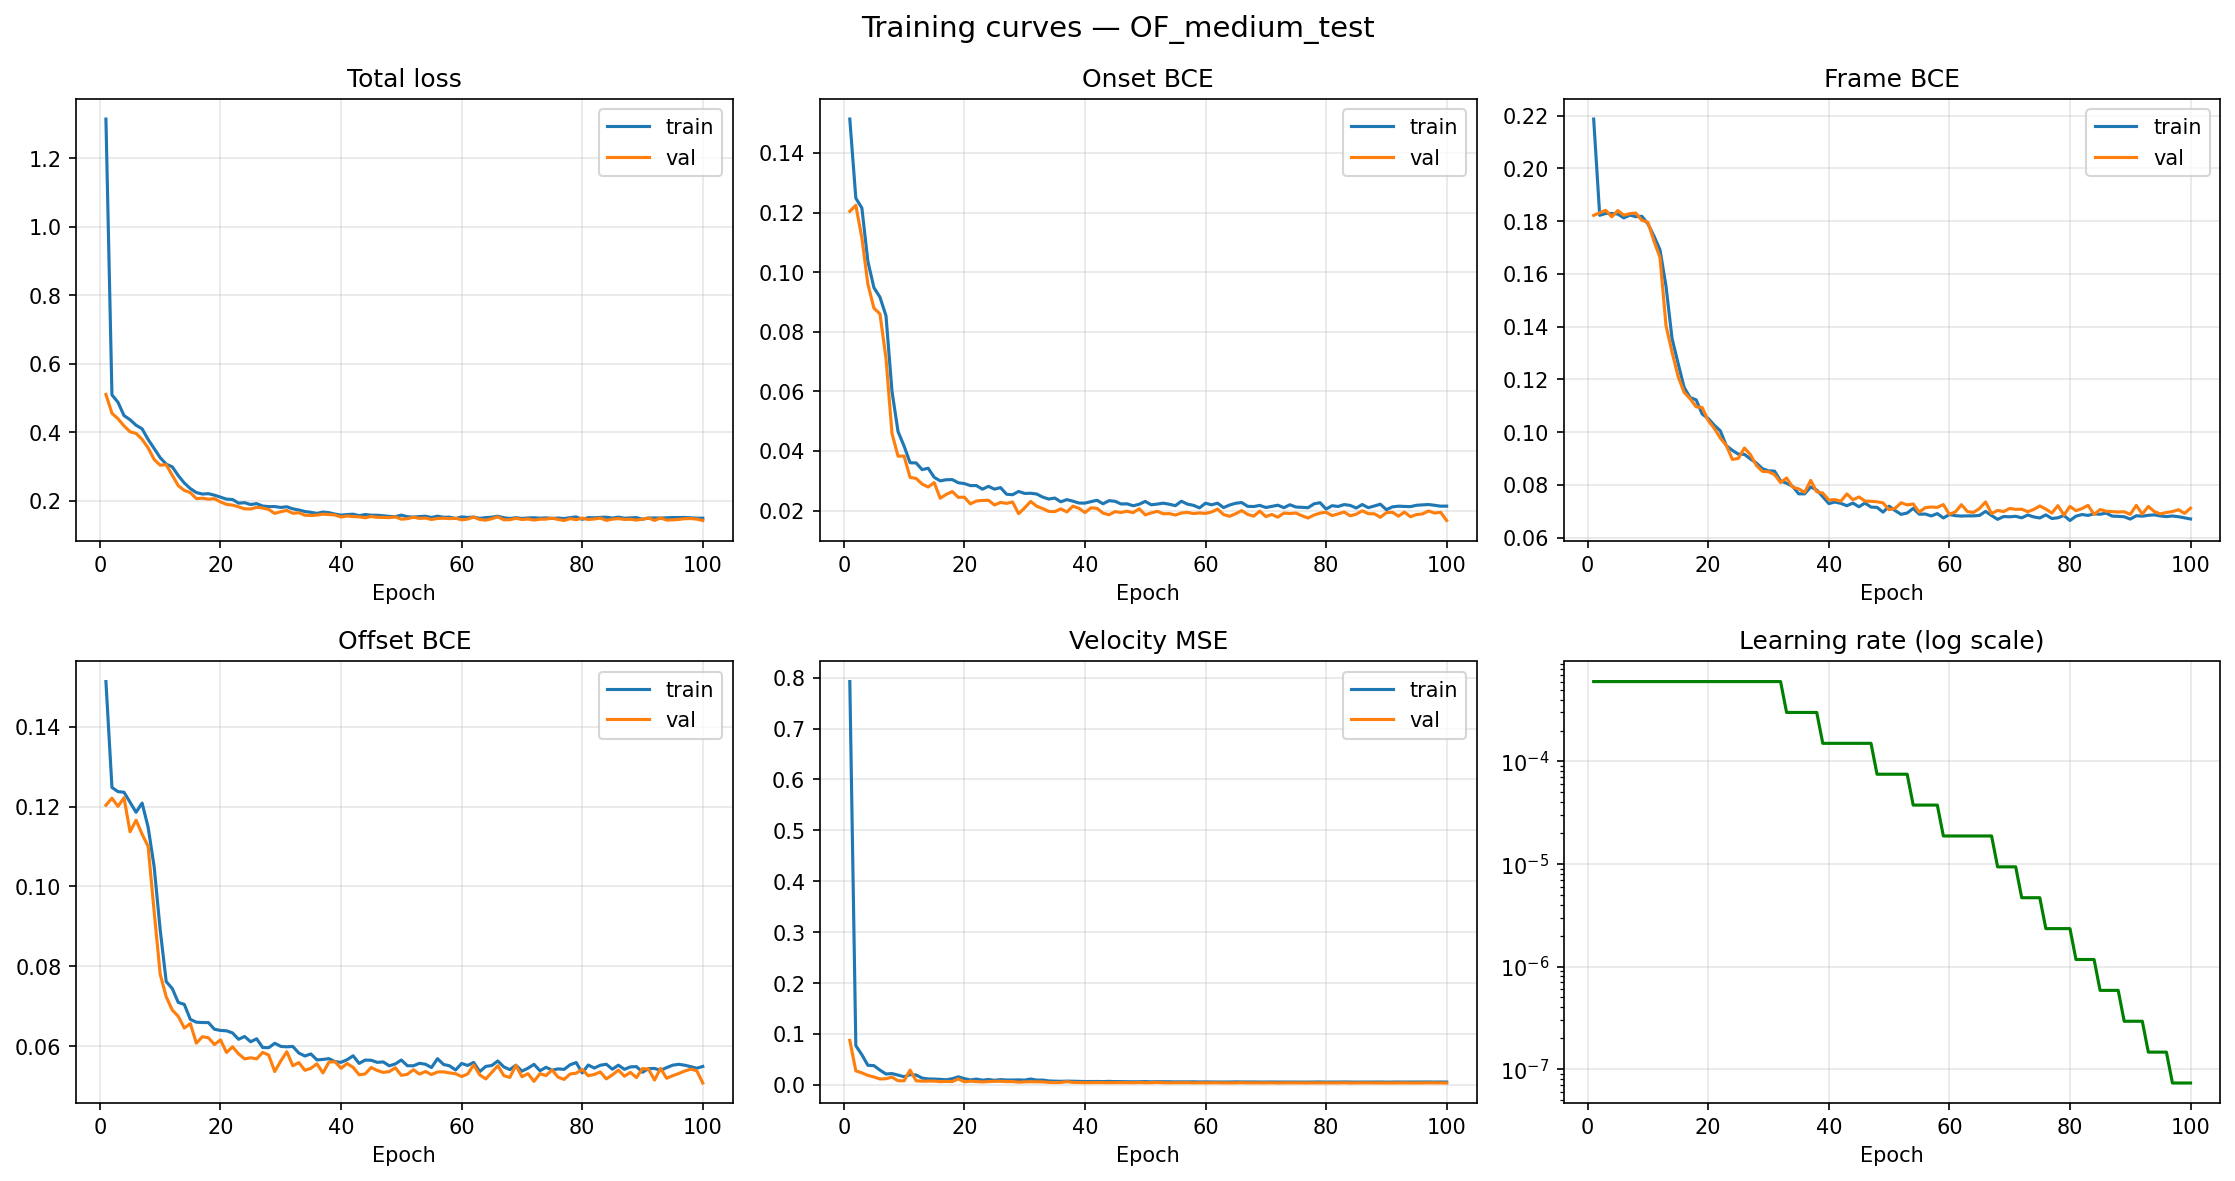

In [ ]:
import matplotlib
matplotlib.use('Agg')   # headless
import matplotlib.pyplot as plt
import json

from evaluate.plots import plot_training_curves

metrics_path = run_dir.root / 'metrics.json'
save_path    = run_dir.plots / 'training_curves_final.png'

plot_training_curves(
    metrics_path = metrics_path,
    save_path    = save_path,
    title        = f"Training curves — {CONFIG['run_name']}",
)

# Also display in notebook
from IPython.display import Image
Image(str(save_path))

## Cell 7 — Evaluate on validation set

Runs the best checkpoint on the validation split and computes all AMT metrics.
Results saved to `runs/<run_name>/eval_validation/`.

In [ ]:
from models.onsets_frames.evaluate import run_evaluation

import mir_eval


# best_ckpt = str(run_dir.best_checkpoint_path())
# print(f"Evaluating: {best_ckpt}")
best_ckpt = "/content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt"
print(f"Evaluating: {best_ckpt}")


val_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'validation',
    max_files        = CONFIG['max_files'],    # same subset for fair comparison
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
    onset_threshold  = 0.5,
    frame_threshold  = 0.5,
    onset_tolerance  = 0.05,
    offset_ratio     = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,

)



Evaluating: /content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt
Device: NVIDIA A100-SXM4-80GB
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt
  Trained for 100 epochs, val_loss=0.1421
  Model parameters: 26,491,256

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference

  Evaluated 137/137 files in 1908.3s

          — Decoding + evaluation protocol —        
  Decode thresholds:
    onset_threshold:   0.50
    frame_threshold:   0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2

  Results saved → /content/drive/MyDrive/piano_amt/runs/OF_medium_test/eval_validation


  EVALUATION SUMMARY — validation split (n=137)
  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 param

## Cell 8 — Evaluate on test set

Only run this once per stage (after hyperparameters are finalised).
Results saved to `runs/<run_name>/eval_test/`.

In [ ]:
from models.onsets_frames.evaluate import run_evaluation

import mir_eval



best_ckpt = "/content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt"
print(f"Evaluating: {best_ckpt}")


test_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'test',
    max_files        = CONFIG['max_files'],
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
    onset_threshold  = 0.5,
    frame_threshold  = 0.5,
    onset_tolerance  = 0.05,
    offset_ratio     = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,

)



Evaluating: /content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt
Device: NVIDIA A100-SXM4-80GB
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_medium_test/checkpoints/best.pt
  Trained for 100 epochs, val_loss=0.1421
  Model parameters: 26,491,256

Evaluating 177/177 files from 'test' split...
  Strategy: full-length single-pass inference (cuDNN disabled for LSTM)
  Thresholds: onset=0.5, frame=0.5
  [10/177] MIDI-Unprocessed_04_R3_2011_MID--AUDIO_R... 5.6s
  [20/177] MIDI-Unprocessed_10_R2_2008_01-05_ORIG_M... 4.2s
  [30/177] MIDI-Unprocessed_14_R1_2008_01-05_ORIG_M... 6.0s
  [40/177] MIDI-Unprocessed_04_R3_2008_01-07_ORIG_M... 10.8s
  [50/177] MIDI-Unprocessed_08_R1_2009_01-04_ORIG_M... 6.3s
  [60/177] MIDI-Unprocessed_23_R2_2011_MID--AUDIO_R... 7.0s
  [70/177] MIDI-Unprocessed_03_R1_2009_03-08_ORIG_M... 10.6s
  [80/177] MIDI-Unprocessed_24_R1_2011_MID--AUDIO_R... 3.9s
  [90/177] MIDI-Unprocessed_22_R2_2011_MID--AUDIO_R... 10.6s
  [100/177] ORIG-MIDI_0

In [ ]:
from src.dataset import load_from_cache, _cache_path
from src.constants import MAX_SEGMENT_FRAMES, FRAMES_PER_SECOND
import torch, pandas as pd
from pathlib import Path

# Load one file directly
csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
val_df = df[df["split"] == "validation"].reset_index(drop=True)
row = val_df.iloc[0]
audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
cp = _cache_path(audio_path, CACHE_DIR)

data = load_from_cache(cp)
mel = data["mel"]  # (229, T)

# Run model
model.eval()
with torch.no_grad():
    out = model(mel.unsqueeze(0).to(device))

pred_onset = out["onset"][0].cpu()   # (T, 88)
pred_frame = out["frame"][0].cpu()

print(f"mel shape      : {mel.shape}")
print(f"pred_onset     : min={pred_onset.min():.4f}  max={pred_onset.max():.4f}  mean={pred_onset.mean():.4f}")
print(f"pred_frame     : min={pred_frame.min():.4f}  max={pred_frame.max():.4f}  mean={pred_frame.mean():.4f}")
print(f"onset > 0.5    : {(pred_onset > 0.5).sum().item()} frames")
print(f"frame > 0.5    : {(pred_frame > 0.5).sum().item()} frames")
print(f"gt onset sum   : {data['onset'].sum().item():.0f}")
print(f"gt frame sum   : {data['frame'].sum().item():.0f}")

mel shape      : torch.Size([229, 12510])
pred_onset     : min=0.4385  max=0.5575  mean=0.5022
pred_frame     : min=0.4568  max=0.5540  mean=0.5002
onset > 0.5    : 645568 frames
frame > 0.5    : 584784 frames
gt onset sum   : 4019
gt frame sum   : 20320


In [ ]:
import json
with open('/content/drive/MyDrive/piano_amt/runs/OF_medium_test/metrics.json') as f:
    m = json.load(f)
print("Onset loss first 5 epochs:", m['train_onset'][:5])
print("Onset loss last 5 epochs:",  m['train_onset'][-5:])
print("Val loss progression:",       m['val_loss'][:10])

Onset loss first 5 epochs: [0.15136526666581632, 0.12481648840010166, 0.12154743149876594, 0.10359136916697026, 0.09480066314339637]
Onset loss last 5 epochs: [0.02190119670704007, 0.022012700131163, 0.021764568015933038, 0.021466331565752627, 0.02147908365353942]
Val loss progression: [0.5101123293385889, 0.4550464109782755, 0.43907734882222477, 0.4181925382492316, 0.4009467074035728, 0.3962444299764007, 0.37898750418294086, 0.3539101929560195, 0.3201494769458353, 0.30361679283371806]


In [ ]:
# Run this on your actual data to get the exact value
import torch
from src.dataset import MAESTRODataset, _cache_path
from src.constants import MAX_SEGMENT_FRAMES
from pathlib import Path
import pandas as pd

csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
train_df = df[df["split"] == "train"].head(100)

total_pos = 0
total_neg = 0

for _, row in train_df.iterrows():
    audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
    cp = _cache_path(audio_path, CACHE_DIR)
    if cp.exists():
        import numpy as np
        data = np.load(str(cp))
        onset = data["onset"]
        total_pos += (onset > 0.5).sum()
        total_neg += (onset <= 0.5).sum()

ratio = total_neg / total_pos
print(f"Negative frames : {total_neg:,}")
print(f"Positive frames : {total_pos:,}")
print(f"Ratio (theoretical pos_weight): {ratio:.1f}")

Negative frames : 136,721,063
Positive frames : 474,281
Ratio (theoretical pos_weight): 288.3


In [ ]:
# Look at one file's onset roll directly
import numpy as np
from src.dataset import _cache_path
from pathlib import Path
import pandas as pd

csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
row = df[df["split"] == "train"].iloc[0]
audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
cp = _cache_path(audio_path, CACHE_DIR)

data = np.load(str(cp))
onset  = data["onset"]
frame  = data["frame"]

print(f"Piece length       : {onset.shape[0]} frames")
print(f"Onset shape        : {onset.shape}")
print(f"Onset sum          : {(onset > 0.5).sum()}")
print(f"Frame sum          : {(frame > 0.5).sum()}")
print(f"Onset max value    : {onset.max():.4f}")
print(f"Onset unique values: {np.unique(onset[:100, :20])}")
print(f"Onset ratio        : {(onset <= 0.5).sum() / max((onset > 0.5).sum(), 1):.1f}")
print(f"Frame ratio        : {(frame <= 0.5).sum() / max((frame > 0.5).sum(), 1):.1f}")

Piece length       : 22009 frames
Onset shape        : (22009, 88)
Onset sum          : 4197
Frame sum          : 56300
Onset max value    : 1.0000
Onset unique values: [0.]
Onset ratio        : 460.5
Frame ratio        : 33.4
